# Домашнее задание: Сбор данных и разметка: от формулировки задачи до крауда

В этом кейсе вы пройдёте путь **от постановки бизнеса** до **пайплайна гибридной разметки**:  
Постановка задачи → разметка zero shot промптом с помощью LLM → оценка качества → Улучшение качества промпта: few-shot, cot и другие способы → Оценка уверенности ответа




### Установка зависимостей

In [1]:
import torch, json, random, re, pandas as pd, numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from sklearn.metrics import precision_recall_fscore_support
from tqdm.auto import tqdm
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cuda


In [2]:
# !pip uninstall -y fsspec datasets
# !pip install fsspec==2024.2.0 datasets==2.18.0

## 1. Постановка задачи


**Контекст (от лица бизнеса):**
Наша компания разрабатывает финтех-приложение с поддержкой пользователей через чат-бот.
Мы хотим автоматически определять тему запроса клиента (например: "блокировка карты", "потеря ПИН-кода", "перевыпуск карты", и т.д.), чтобы быстро направлять клиента к нужному решению. Требуется получить данные для задачи




**Описание задачи:**
> "Для каждого входящего текстового сообщения пользователя автоматически определить одну из тематик (например, balance, card_not_working, transfer, etc.)"

## 2. Требования и бизнес-метрики – 1 балл

Предложите не менее 2 бизнес-метрик, которые может хотеть оптимизировать бизнес относительно процесса разметки данных для данной задачи.


In [3]:
# ваш ответ тут

# ---- Ваш код здесь ----
print("""
Например,
- Среднее время маршрутизации обращения: время от получения сообщения до назначения корректной темы/очереди поддержки. 
  Улучшение метрики показывает, что клиент быстрее попадает к нужному специалисту.
- Доля обращений, обработанных автоматически без ручной классификации: процент сообщений, для которых LLM уверенно 
  назначила intent и не потребовалась проверка оператором. Метрика отражает снижение нагрузки на поддержку.
- Стоимость классификации одного обращения: суммарные затраты на LLM-инференс и ручную проверку, делённые на число 
  обработанных обращений. Метрика показывает экономический эффект от гибридной схемы LLM + human-in-the-loop.
  """)
# ---- Конец кода ----


Например,
- Среднее время маршрутизации обращения: время от получения сообщения до назначения корректной темы/очереди поддержки. 
  Улучшение метрики показывает, что клиент быстрее попадает к нужному специалисту.
- Доля обращений, обработанных автоматически без ручной классификации: процент сообщений, для которых LLM уверенно 
  назначила intent и не потребовалась проверка оператором. Метрика отражает снижение нагрузки на поддержку.
- Стоимость классификации одного обращения: суммарные затраты на LLM-инференс и ручную проверку, делённые на число 
  обработанных обращений. Метрика показывает экономический эффект от гибридной схемы LLM + human-in-the-loop.
  


## 3. Сведение к ML-задаче – 2 балла



Сведите бизнес-задачу к задаче машинного обучения, опишите входные данные и метки:

- **Тип задачи**: классификация
- **Объект**: текст сообщения клиента
- **Метки**: тема обращения

In [4]:
# ваш ответ тут

# ---- Ваш код здесь ----
print("""
- **Тип задачи**: классификация
- **Объект**: текст сообщения клиента
- **Метки**: тема обращения
""")
# ---- Конец кода ----


- **Тип задачи**: классификация
- **Объект**: текст сообщения клиента
- **Метки**: тема обращения



## 4. ML-метрики – 2 балла


Сформулируйте, какие метрики вы будете отслеживать в процессе сбора данных и получения разметки: как при помощи LLM, так и при помощи разметчиков в крауде

In [5]:
# ---- Ваш код здесь ----
print("""
- LLM разметчик: 
    - accuracy, 
    - entropy, H(p) = − sum\\i(p\\i*log(p\\i))
    - macro-f1, 
- Разметчики в крауде: 
    - accuracy, 
    - macro-f1, 
    - Krippendorff’s alpha (для оценки согласованности между разметчиками), 
    - время разметки одного обращения (для оценки эффективности)

- Доля случаев, где нужен арбитр (когда разметчики в крауде не согласны между 
собой или с LLM) - насколько часто возникает необходимость в дополнительной 
проверке и может указывать на сложность задачи или качество разметки.
""")
# ---- Конец кода ----




- LLM разметчик: 
    - accuracy, 
    - entropy, H(p) = − sum\i(p\i*log(p\i))
    - macro-f1, 
- Разметчики в крауде: 
    - accuracy, 
    - macro-f1, 
    - Krippendorff’s alpha (для оценки согласованности между разметчиками), 
    - время разметки одного обращения (для оценки эффективности)

- Доля случаев, где нужен арбитр (когда разметчики в крауде не согласны между 
собой или с LLM) - насколько часто возникает необходимость в дополнительной 
проверке и может указывать на сложность задачи или качество разметки.



## 5. Данные и бейзлайн разметка

### 5.1 Загрузка и первичный анализ датасета

Посмотрим данные: примеры из датасета (попробуем разметить сами хотя бы 10 примеров), все типы меток, размеры выборок, распределение

In [6]:
# !pip uninstall -y fsspec datasets
# !pip install fsspec==2024.2.0 datasets==2.18.0

from datasets import load_dataset, Dataset
import pandas as pd

ds = load_dataset('banking77')


# ---- Ваш код здесь ----
print("""
Считываем данные
""")
# ---- Конец кода ----


Считываем данные



In [91]:
import polars as pl
import polars.selectors as cs
from great_tables import style, loc

pl.Config(fmt_str_lengths=100)


df = pl.concat(
    [
        dataset.to_polars().with_columns(pl.lit(split).alias("split"))
        for split, dataset in ds.items()
    ],
    how="vertical_relaxed",
)

labels = pl.DataFrame(
    {"intent": ds["test"].info.features["label"].names}
).with_row_index("label")

df = df.join(labels, on="label")

# Пример данных
(
    df.sample(5).style.tab_header(
        title="Пример размеченных данных",
        subtitle=f"выборок: {df['split'].n_unique()}, классов: {df['intent'].n_unique()}",
    )
)


GT(_tbl_data=shape: (5, 4)
┌──────────────────────────────────────────────────────┬───────┬───────┬───────────────────────────┐
│ text                                                 ┆ label ┆ split ┆ intent                    │
│ ---                                                  ┆ ---   ┆ ---   ┆ ---                       │
│ str                                                  ┆ i64   ┆ str   ┆ str                       │
╞══════════════════════════════════════════════════════╪═══════╪═══════╪═══════════════════════════╡
│ I have found my lost or stolen card. Is there a way  ┆ 13    ┆ test  ┆ card_linking              │
│ I can link the card with my account through my a…    ┆       ┆       ┆                           │
│ An ATM machine didn't give me back my card.          ┆ 18    ┆ train ┆ card_swallowed            │
│ Please cancel my most recent transfer, it was a      ┆ 8     ┆ train ┆ cancel_transfer           │
│ mistake. This is an emergency. It needs to be        ┆       ┆       ┆                           │
│ cancel…                                              ┆       ┆       ┆                           │
│ The app failed to verify my id.                      ┆ 68    ┆ train ┆ unable_to_verify_identity │
│ I want to start using my card.                       ┆ 0     ┆ train ┆ activate_my_card          │
└──────────────────────────────────────────────────────┴───────┴───────┴───────────────────────────┘, _body=<great_tables._gt_data.Body object at 0x700625e76330>, _boxhead=Boxhead([ColInfo(var='text', type=<ColInfoTypeEnum.default: 1>, column_label='text', column_align='left', column_width=None), ColInfo(var='label', type=<ColInfoTypeEnum.default: 1>, column_label='label', column_align='right', column_width=None), ColInfo(var='split', type=<ColInfoTypeEnum.default: 1>, column_label='split', column_align='left', column_width=None), ColInfo(var='intent', type=<ColInfoTypeEnum.default: 1>, column_label='intent', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x700625cff7a0>, _spanners=Spanners([]), _heading=Heading(title='Пример размеченных данных', subtitle='выборок: 2, классов: 77', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x700625d12510>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x700625d10e90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x700625d12ab0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=

In [8]:
# Распределение классов по сплитам

df.group_by("split").agg(pl.col("label").n_unique())

split,label
str,u32
"""train""",77
"""test""",77


In [9]:
# Уникальные intent, содержащие не буквенные символы (например, вопросительные знаки)
df.filter(pl.col("intent").str.contains(r'\W'))['intent'].unique()

intent
str
"""reverted_card_payment?"""


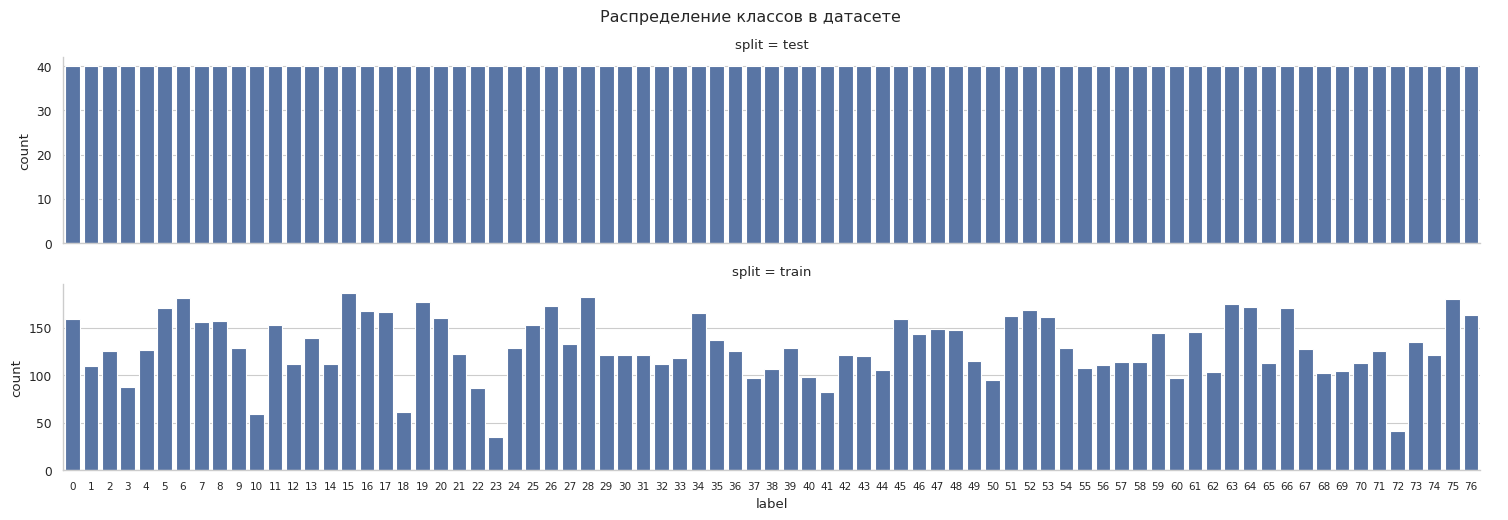

In [28]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme("paper", "whitegrid", rc={"xtick.labelsize": 7.5})


g = sns.catplot(
    data=df,
    kind="count",
    row="split",
    row_order=["test", "train"],
    x="label",
    height=2.5,
    aspect=6,
    sharey=False,
)

plt.suptitle("Распределение классов в датасете", y=1.03)
plt.show()

In [88]:
_df = df.with_columns(pl.col("text").str.split(" ").list.len().alias("text_length"))

_df = (
    _df.group_by("split", "label", "intent")
    .agg(
        pl.min("text_length").cast(pl.Float64).alias("min"),
        pl.quantile("text_length", 0.25).alias("q1"),
        pl.mean("text_length").alias("mean"),
        pl.median("text_length").alias("median"),
        pl.quantile("text_length", 0.75).alias("q3"),
        pl.max("text_length").cast(pl.Float64).alias("max"),
        pl.len().alias("count")
        )
    .sort("label", "split")
)

(
_df
    .style
    .fmt_number(columns=cs.float(), decimals=3)
    .tab_header(
        title="Распределение длин текстов по классам и сплитам",
        subtitle="сравнение статистик между train и test для каждого класса",
    )
    .show()
)

Распределение длин текстов по классам и сплитам 
 
 
 сравнение статистик между train и test для каждого класса 
 
 
 split 
 label 
 intent 
 min 
 q1 
 mean 
 median 
 q3 
 max 
 count 
 
 
 
 
 test 
 0 
 activate_my_card 
 3.000 
 7.000 
 9.275 
 9.000 
 11.000 
 19.000 
 40 
 
 
 train 
 0 
 activate_my_card 
 3.000 
 7.000 
 9.170 
 9.000 
 11.000 
 20.000 
 159 
 
 
 test 
 1 
 age_limit 
 5.000 
 8.000 
 10.000 
 10.500 
 12.000 
 15.000 
 40 
 
 
 train 
 1 
 age_limit 
 4.000 
 7.000 
 9.236 
 9.000 
 11.000 
 17.000 
 110 
 
 
 test 
 2 
 apple_pay_or_google_pay 
 4.000 
 8.000 
 10.500 
 9.500 
 13.000 
 25.000 
 40 
 
 
 train 
 2 
 apple_pay_or_google_pay 
 5.000 
 8.000 
 10.341 
 9.000 
 12.000 
 23.000 
 126 
 
 
 test 
 3 
 atm_support 
 4.000 
 6.000 
 7.475 
 7.000 
 9.000 
 12.000 
 40 
 
 
 train 
 3 
 atm_support 
 4.000 
 6.000 
 7.690 
 8.000 
 9.000 
 13.000 
 87 
 
 
 test 
 4 
 automatic_top_up 
 4.000 
 7.000 
 10.250 
 10.000 
 12.000 
 22.000 
 40 
 
 
 train 
 4 
 automatic_top_up 
 4.000 
 7.000 
 9.079 
 8.000 
 11.000 
 18.000 
 127 
 
 
 test 
 5 
 balance_not_updated_after_bank_transfer 
 4.000 
 9.000 
 13.475 
 11.000 
 13.000 
 36.000 
 40 
 
 
 train 
 5 
 balance_not_updated_after_bank_transfer 
 4.000 
 8.000 
 14.778 
 11.000 
 21.000 
 44.000 
 171 
 
 
 test 
 6 
 balance_not_updated_after_cheque_or_cash_deposit 
 4.000 
 10.000 
 14.050 
 11.500 
 15.000 
 40.000 
 40 
 
 
 train 
 6 
 balance_not_updated_after_cheque_or_cash_deposit 
 5.000 
 10.000 
 14.293 
 13.000 
 17.000 
 43.000 
 181 
 
 
 test 
 7 
 beneficiary_not_allowed 
 5.000 
 8.000 
 12.550 
 10.000 
 15.000 
 31.000 
 40 
 
 
 train 
 7 
 beneficiary_not_allowed 
 3.000 
 7.000 
 12.455 
 9.500 
 14.000 
 57.000 
 156 
 
 
 test 
 8 
 cancel_transfer 
 4.000 
 6.000 
 11.175 
 9.000 
 12.000 
 30.000 
 40 
 
 
 train 
 8 
 cancel_transfer 
 2.000 
 7.000 
 14.153 
 10.000 
 21.000 
 43.000 
 157 
 
 
 test 
 9 
 card_about_to_expire 
 5.000 
 10.000 
 13.550 
 13.000 
 16.000 
 30.000 
 40 
 
 
 train 
 9 
 card_about_to_expire 
 4.000 
 9.000 
 12.054 
 11.000 
 14.000 
 29.000 
 129 
 
 
 test 
 10 
 card_acceptance 
 4.000 
 6.000 
 7.375 
 7.000 
 9.000 
 14.000 
 40 
 
 
 train 
 10 
 card_acceptance 
 4.000 
 6.000 
 7.475 
 8.000 
 9.000 
 11.000 
 59 
 
 
 test 
 11 
 card_arrival 
 5.000 
 6.000 
 10.600 
 10.500 
 14.000 
 20.000 
 40 
 
 
 train 
 11 
 card_arrival 
 4.000 
 8.000 
 10.458 
 10.000 
 13.000 
 23.000 
 153 
 
 
 test 
 12 
 card_delivery_estimate 
 4.000 
 6.000 
 8.200 
 8.000 
 10.000 
 16.000 
 40 
 
 
 train 
 12 
 card_delivery_estimate 
 4.000 
 7.000 
 9.080 
 8.000 
 10.000 
 20.000 
 112 
 
 
 test 
 13 
 card_linking 
 6.000 
 8.000 
 11.300 
 10.500 
 14.000 
 24.000 
 40 
 
 
 train 
 13 
 card_linking 
 5.000 
 10.000 
 12.554 
 12.000 
 15.000 
 31.000 
 139 
 
 
 test 
 14 
 card_not_working 
 3.000 
 5.000 
 7.625 
 7.000 
 10.000 
 14.000 
 40 
 
 
 train 
 14 
 card_not_working 
 4.000 
 7.000 
 9.884 
 9.000 
 11.000 
 38.000 
 112 
 
 
 test 
 15 
 card_payment_fee_charged 
 5.000 
 8.000 
 12.750 
 11.000 
 12.000 
 43.000 
 40 
 
 
 train 
 15 
 card_payment_fee_charged 
 5.000 
 10.000 
 14.005 
 12.000 
 15.000 
 43.000 
 187 
 
 
 test 
 16 
 card_payment_not_recognised 
 5.000 
 8.000 
 14.200 
 11.500 
 19.000 
 46.000 
 40 
 
 
 train 
 16 
 card_payment_not_recognised 
 4.000 
 8.000 
 14.827 
 11.000 
 17.000 
 64.000 
 168 
 
 
 test 
 17 
 card_payment_wrong_exchange_rate 
 7.000 
 10.000 
 12.525 
 12.000 
 14.000 
 22.000 
 40 
 
 
 train 
 17 
 card_payment_wrong_exchange_rate 
 5.000 
 10.000 
 13.269 
 12.000 
 16.000 
 35.000 
 167 
 
 
 test 
 18 
 card_swallowed 
 4.000 
 8.000 
 10.825 
 10.000 
 11.000 
 40.000 
 40 
 
 
 train 
 18 
 card_swallowed 
 4.000 
 8.000 
 10.377 
 10.000 
 12.000 
 30.000 
 61 
 
 
 test 
 19 
 cash_withdrawal_charge 
 6.000 
 9.000 
 14.725 
 11.500 
 15.000 
 63.000 
 40 
 
 
 train 
 19 
 cash_withdrawal_charge 
 4

In [98]:
(
    _df
    .with_columns(
        (pl.col("min") - pl.col("min").shift().over("label")).abs().alias("min_diff"),
        (pl.col("q1") - pl.col("q1").shift().over("label")).abs().alias("q1_diff"),
        (pl.col("mean") - pl.col("mean").shift().over("label")).abs().alias("mean_diff"),
        (pl.col("median") - pl.col("median").shift().over("label")).abs().alias("median_diff"),
        (pl.col("q3") - pl.col("q3").shift().over("label")).abs().alias("q3_diff"),
        (pl.col("max") - pl.col("max").shift().over("label")).abs().alias("max_diff"),
        )
    .select("label", "intent", cs.contains("diff"))
    .filter(pl.col("mean_diff").is_not_null())
    .style
    .fmt_number(columns=cs.float(), decimals=3)
    .tab_header(
        title="Распределения длин текстов по классам и сплитам",
        subtitle="сравнение статистик между train и test для каждого класса",
    )
    .tab_style(
    style=style.fill(color="green"),
    locations=[
        loc.body(columns="min_diff", rows=pl.col("mean_diff") < 3),
    ]
)
)

GT(_tbl_data=shape: (77, 8)
┌───────┬──────────────────────┬──────────┬─────────┬───────────┬─────────────┬─────────┬──────────┐
│ label ┆ intent               ┆ min_diff ┆ q1_diff ┆ mean_diff ┆ median_diff ┆ q3_diff ┆ max_diff │
│ ---   ┆ ---                  ┆ ---      ┆ ---     ┆ ---       ┆ ---         ┆ ---     ┆ ---      │
│ i64   ┆ str                  ┆ f64      ┆ f64     ┆ f64       ┆ f64         ┆ f64     ┆ f64      │
╞═══════╪══════════════════════╪══════════╪═════════╪═══════════╪═════════════╪═════════╪══════════╡
│ 0     ┆ activate_my_card     ┆ 0.0      ┆ 0.0     ┆ 0.105189  ┆ 0.0         ┆ 0.0     ┆ 1.0      │
│ 1     ┆ age_limit            ┆ 1.0      ┆ 1.0     ┆ 0.763636  ┆ 1.5         ┆ 1.0     ┆ 2.0      │
│ 2     ┆ apple_pay_or_google_ ┆ 1.0      ┆ 0.0     ┆ 0.15873   ┆ 0.5         ┆ 1.0     ┆ 2.0      │
│       ┆ pay                  ┆          ┆         ┆           ┆             ┆         ┆          │
│ 3     ┆ atm_support          ┆ 0.0      ┆ 0.0     ┆ 0.214655  ┆ 1.0         ┆ 0.0     ┆ 1.0      │
│ 4     ┆ automatic_top_up     ┆ 0.0      ┆ 0.0     ┆ 1.17126   ┆ 2.0         ┆ 1.0     ┆ 4.0      │
│ …     ┆ …                    ┆ …        ┆ …       ┆ …         ┆ …           ┆ …       ┆ …        │
│ 72    ┆ virtual_card_not_wor ┆ 0.0      ┆ 2.0     ┆ 1.084756  ┆ 1.0         ┆ 2.0     ┆ 1.0      │
│       ┆ king                 ┆          ┆         ┆           ┆             ┆         ┆          │
│ 73    ┆ visa_or_mastercard   ┆ 1.0      ┆ 1.0     ┆ 0.39537   ┆ 1.0         ┆ 1.0     ┆ 3.0      │
│ 74    ┆ why_verify_identity  ┆ 1.0      ┆ 1.0     ┆ 0.013843  ┆ 1.0         ┆ 0.0     ┆ 3.0      │
│ 75    ┆ wrong_amount_of_cash ┆ 2.0      ┆ 1.0     ┆ 0.147222  ┆ 0.0         ┆ 2.0     ┆ 10.0     │
│       ┆ _received            ┆          ┆         ┆           ┆             ┆         ┆          │
│ 76    ┆ wrong_exchange_rate_ ┆ 2.0      ┆ 1.0     ┆ 0.941258  ┆ 1.5         ┆ 1.0     ┆ 3.0      │
│       ┆ for_cash_withdrawal  ┆          ┆         ┆           ┆             ┆         ┆          │
└───────┴──────────────────────┴──────────┴─────────┴───────────┴─────────────┴─────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x700625d25010>, _boxhead=Boxhead([ColInfo(var='label', type=<ColInfoTypeEnum.default: 1>, column_label='label', column_align='right', column_width=None), ColInfo(var='intent', type=<ColInfoTypeEnum.default: 1>, column_label='intent', column_align='left', column_width=None), ColInfo(var='min_diff', type=<ColInfoTypeEnum.default: 1>, column_label='min_diff', column_align='right', column_width=None), ColInfo(var='q1_diff', type=<ColInfoTypeEnum.default: 1>, column_label='q1_diff', column_align='right', column_width=None), ColInfo(var='mean_diff', type=<ColInfoTypeEnum.default: 1>, column_label='mean_diff', column_align='right', column_width=None), ColInfo(var='median_diff', type=<ColInfoTypeEnum.default: 1>, column_label='median_diff', column_align='right', column_width=None), ColInfo(var='q3_diff', type=<ColInfoTypeEnum.default: 1>, column_label='q3_diff', column_align='right', column_width=None), ColInfo(var='max_diff', type=<ColInfoTypeEnum.default: 1>, column_label='max_diff', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x700635075490>, _spanners=Spanners([]), _heading=Heading(title='Распределения длин текстов по классам и сплитам', subtitle='сравнение статистик между train и test для каждого класса', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x700625d2d3d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x700625d2c470>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='min_diff', rows=<Expr ['[(col("mean_diff")) < (dyn int…'] at 0x700625D2F5C0>, mask=None), grpname=None, colname='min_diff', rownum=0, colnum=None, styles=[CellStyleFill(color='green')]), StyleInfo(locname=LocBody(columns='min_diff', rows=<Expr ['[(col("mean_diff")) < (dy

### 5.2 Бейзлайн LLM разметка (7 баллов)

В этом пункте нужно получить бейзлайн разметку с помощью open source LLM и простого короткого промпта.

Для упрощения тут у нас уже есть golden set разметка (в случае если не было бы, то действовали как указано в лекции, или бы размечали для начала сами хотя бы 50-100 примеров), на которой мы можем проверять качество

В качестве LLM можно также взять https://huggingface.co/IlyaGusev/saiga_yandexgpt_8b . Либо можно заменить на любую open-source (например "Qwen/Qwen3-8B", "meta-llama/Meta-Llama-3-8B-Instruct", "mistralai/Mistral-7B-Instruct-v0.2", и т.д.)

In [ ]:
# !pip install -U accelerate bitsandbytes transformers

In [ ]:
# ---- Ваш код здесь ----
print("""
    Загружаем выбранную LLM
    В некоторых случаях может понадобиться !pip install -U accelerate bitsandbytes transformers
""")
# ---- Конец кода ----

Формируем простой короткий промпт, в котором укажем  все категории меток для разметки, и потребуем выход в нужном формате json {"label": str}, для которого напишем функцию парсинга



In [ ]:
# ---- Ваш код здесь ----
prompt_template = (
    "Текст промпта для разметки"
    )
# ---- Конец кода ----


Делаем разметку 10-20 примеров, пишем функцию парсинга ответа (считаем метрику в скольких ответах нарушения следования формату), смотрим ответы

In [1]:
# Функция разметки вместе с промптом,

# ---- Ваш код здесь ----
print("""
    прокачиваем в цикле выбранную LLM для разметки данных через функцию annotate, добавляем разметку в исходный датасет и сохраняем в файл
""")
# ---- Конец кода ----



    прокачиваем в цикле выбранную LLM для разметки данных через функцию annotate, добавляем разметку в исходный датасет и сохраняем в файл



### 5.3 Оценка качества (2 балла)

Оцениваем качество разметки на тестовом датасет (либо на семпле из тестового датасета)



In [ ]:
# ---- Ваш код здесь ----
print("""
    Инферим LLM на тесте, замеряем метрики
""")
# ---- Конец кода ----



### 6. Улучшение качества промпта

### 6.1 few shot prompt (4 баллов)

Добавим в промпт few-shot примеры (важно, чтобы не было data leak  c тестом): помогает исправлять поведение модели, когда описание в инструкции не справляется + модель лучше следует форматам

In [ ]:
# ---- Ваш код здесь ----
print("""
    Пишем промпт с few shot, замеряем качество
""")
# ---- Конец кода ----



### 6.2 chain-of-thoughts (3 балла)

Добавляем сhain-of-thought в промпт: требуем короткий reasoning → повышаем прозрачность решения модели (понимаем, почему размечено именно так) и улучшаем качество на более сложных задачах

Json на выходе теперь формата
{"reasoning": "why_this_class", "label": "one_of_the_categories"}

In [ ]:
# ---- Ваш код здесь ----
print("""
    Пишем промпт с few shot, замеряем качество
""")
# ---- Конец кода ----



### 6.3 Дальнейшие улучшения (6 баллов)

Далее улучшаем итеративно

Основные улучшения в общем случае происходит за счет:
- Аналитика ошибок,  в первую очередь анализируем ошибки разметки (только на трейне, чтобы не подогнаться под тест!), в том числе используя reasoning модели, чтобы понять причины. Также помогает спрашивать у самой модели и просить ее поправить начальный промпт/инструкцию

- Понимание бизнеса и домена, четкое описание в инструкции/промпте

Дополнительно, что тут может еще помочь:
- Упрощение задачи: размечать не одну, а несколько наиболее релеватных меток для каждого текста (=> растим recall)

- Использовать более "умные" LLM
- Размечаем с перекрытием: запускаем промпт n раз (например, 3) и агрегируем ответ. Улучшение: агрегурем результат ансамбля разных LLM (среди тех же размеров например: Qwen-3 8b) , можно с тем же промптом, либо промпты могут отлчичаться между собой few shot примерами

Тут нужно реализовать одно из улучшений (из лекции: слайды 39-41, 46, либо списка выше, например, с перекрытием). Цель - улучшить последний результат по accuracy и побить baseline: accuracy = 0.6 на тестовой выборке

In [7]:
# ---- Ваш код здесь ----
print("""
    Промпты с улучшением качества (baseline: accuracy = 0.6), сравнение метрик, как каждое улучшение повляило
""")
# ---- Конец кода ----


    Промпты с улучшением качества (baseline: accuracy = 0.6), сравнение метрик, как каждое улучшение повляило



## 7.1. Уверенность ответа. (11 баллов)

Посчитаем уверенность модели ответов по модели. Полезно для гибкой схемы разметки, когда более сложные примеры отправляются на разметку асессорам, либо на модель побольше, или на доп разметку с доп перекрытием.

Рабочий бейзлайн  - усредение logprob для сгенерированного текста («confidence can be approximated with the average token-level probability of the generated span»)

Здесь нужно написать функцию для взятия уверенности модели, как указано ниже, и далее показать, что числовая «уверенность» (confidence), посчитанная по лог-вероятностям токенов, действительно коррелирует с тем, ошиблась модель или нет. Ожидается получение AUC>=0.6


https://cookbook.openai.com/examples/using_logprobs


In [6]:

# ---- Ваш код здесь ----
def annotate_conf(text: str,
                  max_new_tokens: int = 32
                 ) -> tuple[str, float, int, str]:
    """
    Размечает один запрос при помощи LLM b сразу возвращает числовую
    «уверенность» предсказания на основе лог-вероятностей сгенерированных
    токенов.

    ▸ Логика шага
      1. Формируем prompt (например с few-shot).
      2. Вызываем `model.generate(..., output_scores=True)` — получаем
         логиты (score-векторы) для каждого сгенерированного токена.
      3. Берём JSON-фрагмент ответа; если label не распарсился
         или не входит в `label_names`, ставим `corrupted = 1`.
      4. **Confidence** = `exp(mean(log p))` по токенам JSON-строки
         (кумулятивная вероятность: чем ближе к 1 — тем модель
         «увереннее» в своём выборе).

    Параметры
    ----------
    text : str
        Пользовательский запрос, который нужно классифицировать.
    max_new_tokens : int, optional
        Сколько токенов максимум разрешаем модели сгенерировать
        (включая JSON и возможный «хвост»).  Дефолт — 32.

    Возвращает
    ----------
    label : str
        Предсказанная категория (`label_names` или "other").
    confidence : float
        Уверенность модели (0 – 1).  Расчёт: exp(среднего log p токенов JSON).
    corrupted : int
        0 — JSON корректный и label ∈ `label_names`;
        1 — формат сломан **или** label не из списка.
    raw_generation : str
        Полный ответ LLM (полезно для дебага/визуализации).
    """
    return
# ---- Конец кода ----



In [ ]:
# ---- Ваш код здесь ----
print("""
1. Посчитайте roc_auc_score(y_true_bin, y_score), где
y_true_bin = 1, если модель угадала (`pred_label == true_label`)), иначе 0, y_score = confidence, который вернула annotate_conf
2. Сделайте выводы по полезности confidence
""")
# ---- Конец кода ----


## 8.1. Human-in-the-loop с шумным разметчиком

В реальных задачах разметку часто делают не идеальные эксперты, а обычные асессоры — они тоже ошибаются. Для достижения хорошего качества с ними используется разметка с перкрытием по N accесорам, а затем агрегируется разметка (например majority vote). Таким образом получаем **gold-метку** и меру "уверенности" ассесоров - насколько они сходятся в решении (например 0.75 - из 4 ассессоров 3 выбрали итоговую метку).

Часть разметки можно переложить на LLM, если уметь оценивать его уверенность.

В этом задании мы смоделируем простую схему:

- есть **gold-метка** `true_label` (используем только для оценки качества),
- есть один **"человек"-разметчик** с ошибками (`human_label`),
- есть предсказания LLM: `pred_label` и `confidence`.

Мы хотим построить **гибридную систему**:

- по умолчанию используем метку человека (`human_label`);
- если `confidence >= threshold` — считаем, что LLM очень уверен и берём его метку (`pred_label`).

#### 8.2.1. Симуляция "шумного" разметчика (3 балла)

Реализуйте функцию, которая по gold-меткам `true_labels` возвращает `human_labels`:

- с вероятностью `1 - error_rate` берётся правильная метка,
- с вероятностью `error_rate` — случайная *другая* метка из `label_names`  
  (можно взять, например, `error_rate = 0.25`).

1. Реализуйте функцию `simulate_noisy_human(true_labels, label_names, error_rate=0.25, random_state=42)`.
2. Посчитайте accuracy такого разметчика относительно `true_labels`.

Замечание: в реальных задачах расхождения между разметчиками и ошибочно проставленные метки зачастую не случайны. В данном задании симулируем шум для упрощения.

In [2]:
# ---- Ваш код здесь ----

# ---- Конец кода ----


#### 8.2.2. Гибридная схема разметки (4 балла)

Реализуйте функцию, которая комбинирует разметку человека и LLM по порогу уверенности:

- по умолчанию использует `human_labels`,
- если `confidence[i] >= threshold` — вместо метки человека берёт `pred_labels[i]`,
- возвращает:
  - `overall_acc` — итоговую accuracy гибридной разметки (относительно `true_labels`),
  - `coverage` — долю объектов, где использовали LLM (от 0 до 1).

1. Реализуйте функцию  
   `simulate_hybrid(pred_labels, human_labels, true_labels, confidence, threshold)`.
2. Проверьте её на небольшом игрушечном примере

In [3]:
# ---- Ваш код здесь ----

# ---- Конец кода ----


#### 8.2.3. Подбор порога и анализ trade-off (3 балла)

1. Для `threshold` из диапазона `[0.0, 1.0]` с шагом 0.05:
   - посчитайте `overall_acc` и `coverage`;
   - выведите таблицу с колонками `threshold`, `accuracy`, `coverage`  
     (по желанию можно дополнительно построить график `accuracy` vs `coverage`).
2. Найдите значение `threshold`, при котором:
   - качество гибридной разметки **не ниже** заданного уровня (например, accuracy ≥ 0.8 *относительно gold*),
   - а `coverage` максимально возможен.

In [4]:
# ---- Ваш код здесь ----

# ---- Конец кода ----


#### 8.2.4. Сравнение схем разметки (2 балла)

1. Посчитайте и сравните:
   - accuracy только человека (`human_labels`),
   - accuracy только LLM (`pred_labels`),
   - лучшую точку гибрида.
2. Кратко (2–3 предложения) ответьте:
   - в чём преимущество гибридного подхода по сравнению с «чисто человек» и «чисто LLM»?
   - в каких кейсах такая схема human-in-the-loop может быть особенно полезна?


In [5]:
# ---- Ваш код здесь ----

# ---- Конец кода ----


## Итоги домашки

В этой работе мы посмотрели на разметку как на систему, где есть и люди, и LLM.

Главное, что нужно вынести:
- LLM можно использовать как разметчика (при этом важно следить за качеством ), можно улучшать промт за счет различных прдеставленных способов.
- Оценка **уверенности** по logprobs позволяет решать, где доверять модели, а где подключать человека.
- Гибридная схема human-in-the-loop часто лучше, чем «только крауд» или «только LLM»: мы разгружаем людей на простых примерах и сохраняем качество на сложных.
- Эти идеи масштабируются дальше: улучшение промптов, дообучение модели, active learning и более умные пайплайны разметки.
